In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import re
from collections import Counter
from datetime import datetime
import chardet
import unicodedata

warnings.filterwarnings('ignore')

# Set plot style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12


KCC_PATH = "/content/drive/MyDrive/kcc_raw/"

✅ Libraries imported successfully!


In [7]:
from glob import glob

csv_files = sorted(glob(f"{KCC_PATH}/kcc_up_*.csv"))

print(f"📁 Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  - {Path(f).name}")

📁 Found 6 CSV files:
  - kcc_up_2020.csv
  - kcc_up_2021.csv
  - kcc_up_2022.csv
  - kcc_up_2023.csv
  - kcc_up_2024.csv
  - kcc_up_2025.csv


In [8]:
all_dfs = []
for file in csv_files:
    year = Path(file).stem.split('_')[-1]
    print(f"Loading {Path(file).name}...", end=" ")
    try:
        df = pd.read_csv(file)
        all_dfs.append(df)
        print(f"{len(df):,} records")
    except Exception as e:
        print(f"Error: {e}")

df = pd.concat(all_dfs, ignore_index=True)
print(f"\n Total records: {len(df):,}")
print(f" Total columns: {len(df.columns)}")

Loading kcc_up_2020.csv... ✅ 565,719 records
Loading kcc_up_2021.csv... ✅ 495,222 records
Loading kcc_up_2022.csv... ✅ 620,775 records
Loading kcc_up_2023.csv... ✅ 585,633 records
Loading kcc_up_2024.csv... ✅ 536,048 records
Loading kcc_up_2025.csv... ✅ 319,632 records

✅ Total records: 3,123,029
✅ Total columns: 15


In [28]:
print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
local_path = "kcc_combined_2020_2025.csv"
df.to_csv(local_path, index=False)
file_size = os.path.getsize(local_path) / (1024 * 1024)
print(f" Saved locally: {local_path} ({file_size:.2f} MB)")

  Memory usage: 3339.76 MB
 Saved locally: kcc_combined_2020_2025.csv (2072.42 MB)


In [29]:
drive_path = os.path.join(KCC_PATH, "kcc_combined_2020_2025.csv")
df.to_csv(drive_path, index=False)
print(f"  ✅ Saved to: {drive_path}")

  ✅ Saved to: /content/drive/MyDrive/kcc_raw/kcc_combined_2020_2025.csv


#EDA - NLP/RAG Pipeline

### DATASET OVERVIEW

In [30]:
print("\n" + "="*80)
print("SECTION 1: DATASET OVERVIEW")
print("="*80)

print(f"\n Basic Information:")
print(f"  Total records: {len(df):,}")
print(f"  Total columns: {len(df.columns)}")
print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n Column Information:")
for i, (col, dtype) in enumerate(df.dtypes.items(), 1):
    unique_count = df[col].nunique()
    null_count = df[col].isnull().sum()
    null_pct = (null_count / len(df)) * 100
    print(f"  {i:2d}. {col:15s} → {str(dtype):10s} | Unique: {unique_count:8,} | Null: {null_count:6,} ({null_pct:4.1f}%)")

print("\n First 5 rows:")
display(df.head())

print("\n Statistical Summary (Numeric):")
display(df.describe())




SECTION 1: DATASET OVERVIEW

 Basic Information:
  Total records: 3,123,029
  Total columns: 15
  Memory usage: 3339.76 MB

 Column Information:
   1. BlockName       → object     | Unique:    1,633 | Null:  1,454 ( 0.0%)
   2. Category        → object     | Unique:       40 | Null:  3,779 ( 0.1%)
   3. CreatedOn       → object     | Unique: 3,103,776 | Null:      1 ( 0.0%)
   4. Crop            → object     | Unique:      318 | Null:  6,370 ( 0.2%)
   5. DistrictName    → object     | Unique:       86 | Null:      7 ( 0.0%)
   6. KCCCallID       → int64      | Unique: 2,712,405 | Null:      0 ( 0.0%)
   7. KccAns          → object     | Unique: 1,924,467 | Null:    559 ( 0.0%)
   8. QueryText       → object     | Unique:  976,874 | Null:     12 ( 0.0%)
   9. QueryType       → object     | Unique:       83 | Null:  4,886 ( 0.2%)
  10. Season          → float64    | Unique:        0 | Null: 3,123,029 (100.0%)
  11. Sector          → object     | Unique:      110 | Null:  6,372 ( 0.2%)


,BlockName,Category,CreatedOn,Crop,DistrictName,KCCCallID,KccAns,QueryText,QueryType,Season,Sector,StateName,day,month,year
0,NAWABGANJ,Others,2020-07-23T15:21:41.12,Others,GONDA,2224700,श्रीमान जी प्रधानमंत्री किसान सम्मान निधि योजन...,Information about application status of PM Kis...,Government Schemes,NaN,AGRICULTURE,UTTAR PRADESH,23.0,7.0,2020.0
1,GHAZIPUR,Vegetables,2020-07-23T15:22:02.727,Cowpea (Vegetable),GHAZIPUR,2225064,--सर आप लोबिया की फसल में Dimethoate 30% EC @...,Give information about plant protection of ...,\tPlant Protection\t,NaN,HORTICULTURE,UTTAR PRADESH,23.0,7.0,2020.0
2,MAHMUDABAD,Cereals,2020-07-25T09:45:10.843,Paddy (Dhan),SITAPUR,2240020,"महोदय, धान में टॉप ड्रेसिंग के समय यूरिया 35 k...",Dhaan ki fasal me top dressing ke samay kya pr...,Nutrient Management,NaN,AGRICULTURE,UTTAR PRADESH,25.0,7.0,2020.0
3,KHUDAGANJ KATRA,Cereals,2020-07-25T09:48:24.863,Paddy (Dhan),SHAHJAHANPUR,2241298,"श्रीमान जी धान की फसल में तना बेधक, पत्ती लपेट...",Information about pest management of leaf fold...,\tPlant Protection\t,NaN,AGRICULTURE,UTTAR PRADESH,25.0,7.0,2020.0
4,BILASPUR,Animal,2020-07-25T09:49:39.7,"Bovine(Cow,Buffalo)",RAMPUR,2240697,श्री मान जी आप डेरी स्कीम की जानकारी के लिए जि...,Dairy scheem ki jankari de…?,Disease Management,NaN,ANIMAL HUSBANDRY,UTTAR PRADESH,25.0,7.0,2020.0



 Statistical Summary (Numeric):


,KCCCallID,Season,day,month,year
count,3.123029e+06,0.0,3.123027e+06,3.123027e+06,3.123027e+06
mean,3.364788e+06,NaN,1.563869e+01,6.093401e+00,2.022317e+03
std,2.101280e+06,NaN,8.854212e+00,3.599894e+00,1.605579e+00
min,2.000000e+00,NaN,1.000000e+00,1.000000e+00,2.020000e+03
25%,1.597463e+06,NaN,8.000000e+00,3.000000e+00,2.021000e+03
50%,3.238972e+06,NaN,1.600000e+01,6.000000e+00,2.022000e+03
75%,4.778768e+06,NaN,2.300000e+01,9.000000e+00,2.024000e+03
max,7.816168e+06,NaN,3.100000e+01,1.200000e+01,2.025000e+03


### CROP DISTRIBUTION


SECTION 2: CROP DISTRIBUTION

📊 Total Unique Crops: 318

📋 Top 20 Crops:
 1. Others                              → 1,084,880 (34.74%)
 2. Wheat                               →  512,277 (16.40%)
 3. Paddy (Dhan)                        →  485,427 (15.54%)
 4. Sugarcane (Noble Cane)              →  126,140 ( 4.04%)
 5. Potato                              →  106,906 ( 3.42%)
 6. Mustard                             →   96,708 ( 3.10%)
 7. Maize (Makka)                       →   57,186 ( 1.83%)
 8. Mango                               →   47,484 ( 1.52%)
 9. Black Gram (urd bean)               →   39,564 ( 1.27%)
10. Pea (Vegetable)                     →   36,234 ( 1.16%)
11. Groundnut (pea nut/mung phalli)     →   30,966 ( 0.99%)
12. Mentha                              →   30,482 ( 0.98%)
13. Green Gram (Moong Bean/ Moong)      →   29,823 ( 0.95%)
14. Chillies                            →   25,783 ( 0.83%)
15. Pearl Millet (Bajra/Bulrush Millet/Spiked Millet) →   23,672 ( 0.76%)
16. Bengal 

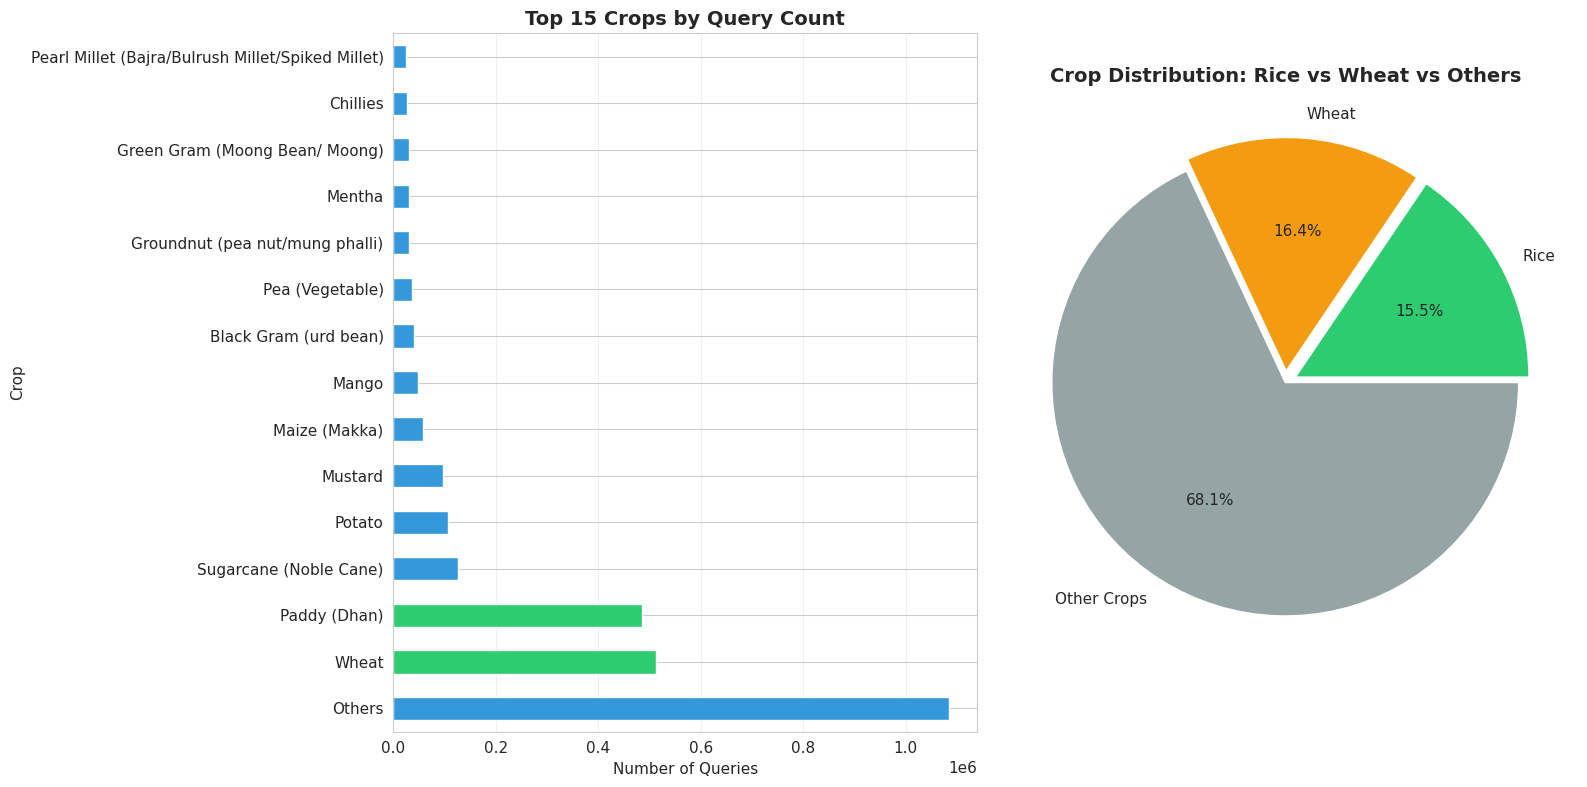

In [32]:
print("\n" + "="*80)
print("SECTION 2: CROP DISTRIBUTION")
print("="*80)

if 'Crop' in df.columns:
    crop_counts = df['Crop'].value_counts()

    print(f"\n📊 Total Unique Crops: {len(crop_counts)}")

    print("\n📋 Top 20 Crops:")
    print("="*60)
    for i, (crop, count) in enumerate(crop_counts.head(20).items(), 1):
        pct = (count / len(df)) * 100
        print(f"{i:2d}. {crop:35s} → {count:8,} ({pct:5.2f}%)")

    # Focus on Rice and Wheat
    rice_pattern = 'Rice|Paddy|Dhan'
    wheat_pattern = 'Wheat|Gehu'

    rice_mask = df['Crop'].str.contains(rice_pattern, case=False, na=False)
    wheat_mask = df['Crop'].str.contains(wheat_pattern, case=False, na=False)

    rice_count = rice_mask.sum()
    wheat_count = wheat_mask.sum()
    combined_count = (rice_mask | wheat_mask).sum()

    print(f"\n Rice and Wheat Analysis:")
    print(f"  Rice queries:  {rice_count:8,} ({rice_count/len(df)*100:.2f}%)")
    print(f"  Wheat queries: {wheat_count:8,} ({wheat_count/len(df)*100:.2f}%)")
    print(f"  Combined:      {combined_count:8,} ({combined_count/len(df)*100:.2f}%)")

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Top 15 crops
    top_crops = crop_counts.head(15)
    colors = ['#2ecc71' if ('Rice' in crop or 'Paddy' in crop or 'Wheat' in crop)
              else '#3498db' for crop in top_crops.index]
    top_crops.plot(kind='barh', ax=axes[0], color=colors)
    axes[0].set_title('Top 15 Crops by Query Count', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Number of Queries')
    axes[0].set_ylabel('Crop')
    axes[0].grid(axis='x', alpha=0.3)

    # Pie - Rice, Wheat, Others
    others = len(df) - combined_count
    axes[1].pie([rice_count, wheat_count, others],
                labels=['Rice', 'Wheat', 'Other Crops'],
                autopct='%1.1f%%',
                colors=['#2ecc71', '#f39c12', '#95a5a6'],
                explode=(0.05, 0.05, 0))
    axes[1].set_title('Crop Distribution: Rice vs Wheat vs Others', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

### QUERY CATEGORY ANALYSIS


SECTION 3: QUERY CATEGORY ANALYSIS

📊 Total Categories: 40

📋 All Categories:
  Others                        : 1,094,171 (35.04%)
  Cereals                       : 1,000,881 (32.05%)
  Vegetables                    :  336,545 (10.78%)
  Oilseeds                      :  153,852 ( 4.93%)
  Sugar and Starch Crops        :  125,927 ( 4.03%)
  Pulses                        :  109,358 ( 3.50%)
  Fruits                        :  100,707 ( 3.22%)
  Millets                       :   86,262 ( 2.76%)
  Medicinal and Aromatic Plants :   34,012 ( 1.09%)
  Condiments and Spices         :   21,454 ( 0.69%)
  Animal                        :   17,182 ( 0.55%)
  Drug and Narcotics            :    9,179 ( 0.29%)
  Fodder Crops                  :    8,136 ( 0.26%)
  Flowers                       :    7,165 ( 0.23%)
  Plantation Crops              :    5,595 ( 0.18%)
  Fiber Crops                   :    2,275 ( 0.07%)
  Green Manure                  :    2,228 ( 0.07%)
  Inland                        :  

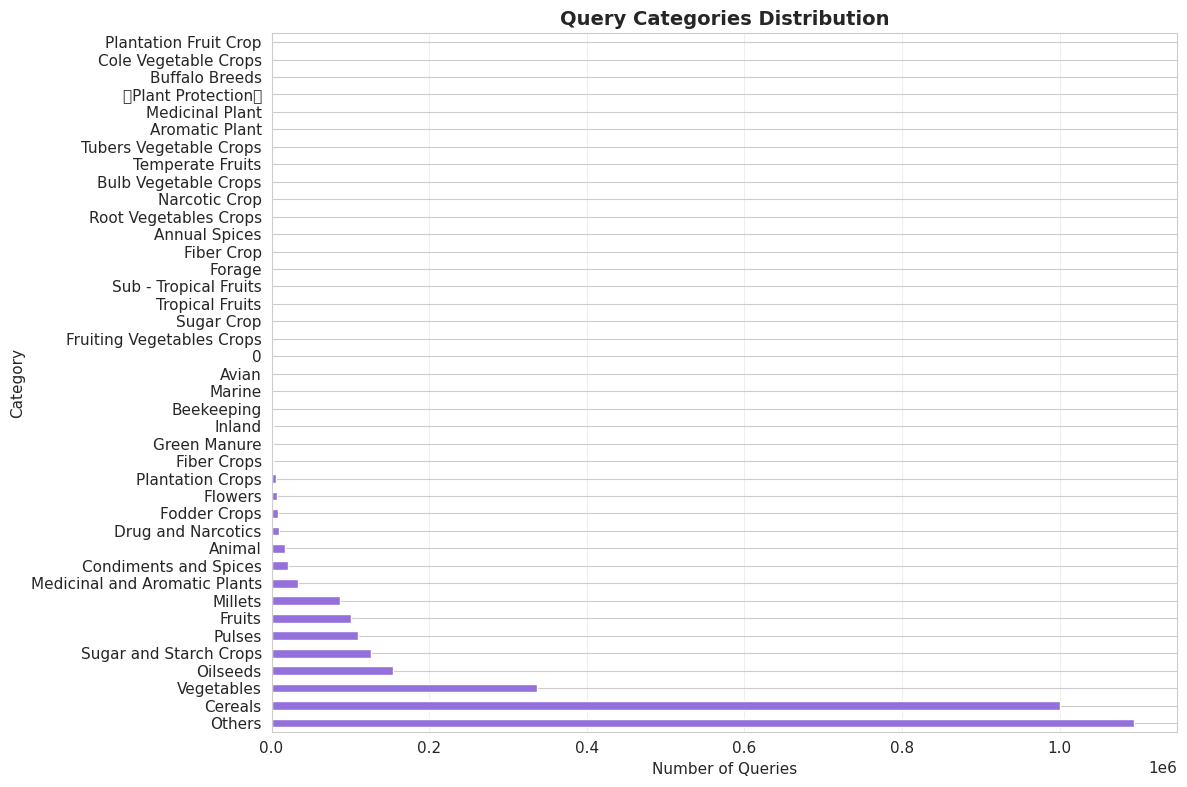


 Total Query Types: 83

 Top 20 Query Types:
 1. Weather                             → 1,045,131 (33.47%)
 2. Government Schemes                  →  800,458 (25.63%)
 3. 	Plant Protection	                  →  433,042 (13.87%)
 4. Cultural Practices                  →  140,827 ( 4.51%)
 5. Fertilizer Use and Availability     →  112,130 ( 3.59%)
 6. Nutrient Management                 →  110,994 ( 3.55%)
 7. 	Water Management	                  →  103,758 ( 3.32%)
 8. Weed Management                     →   79,238 ( 2.54%)
 9. Varieties                           →   62,725 ( 2.01%)
10. Sowing Time and Weather             →   45,468 ( 1.46%)
11. Seeds and Planting Material         →   23,651 ( 0.76%)
12. Market Information                  →   21,433 ( 0.69%)
13. Crop Insurance                      →   16,420 ( 0.53%)
14. Post Harvest Preservation           →   13,635 ( 0.44%)
15. Seeds                               →   13,372 ( 0.43%)
16. Water Management, Micro Irrigation  →   10,607 ( 

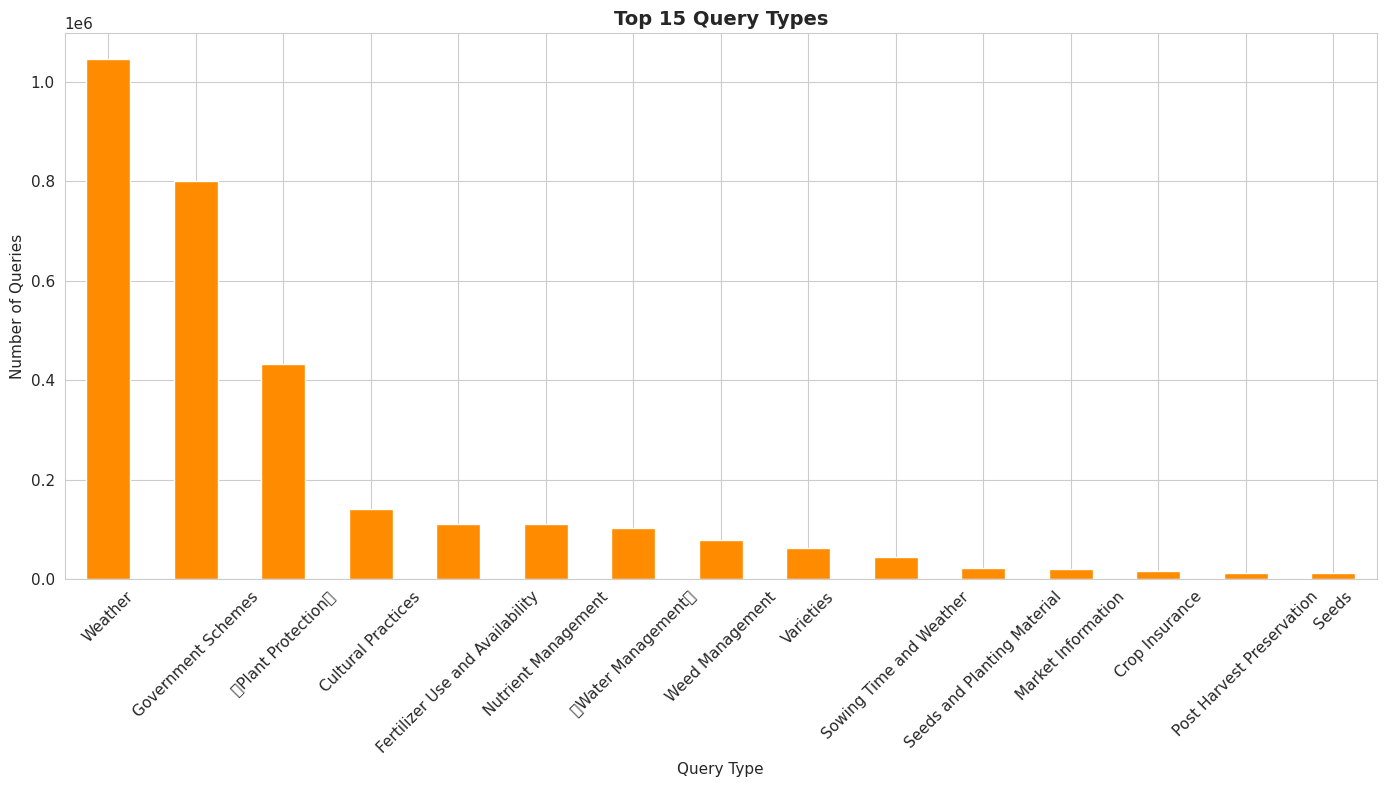

In [33]:
print("\n" + "="*80)
print("SECTION 3: QUERY CATEGORY ANALYSIS")
print("="*80)

if 'Category' in df.columns:
    category_counts = df['Category'].value_counts()

    print(f"\n📊 Total Categories: {len(category_counts)}")

    print("\n📋 All Categories:")
    print("="*60)
    for category, count in category_counts.items():
        pct = (count / len(df)) * 100
        print(f"  {category:30s}: {count:8,} ({pct:5.2f}%)")

    # Visualize
    fig, ax = plt.subplots(figsize=(12, 8))
    category_counts.plot(kind='barh', ax=ax, color='mediumpurple')
    ax.set_title('Query Categories Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Queries')
    ax.set_ylabel('Category')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

if 'QueryType' in df.columns:
    querytype_counts = df['QueryType'].value_counts()

    print(f"\n Total Query Types: {len(querytype_counts)}")

    print("\n Top 20 Query Types:")
    print("="*60)
    for i, (qtype, count) in enumerate(querytype_counts.head(20).items(), 1):
        pct = (count / len(df)) * 100
        print(f"{i:2d}. {qtype:35s} → {count:8,} ({pct:5.2f}%)")

    # Visualize top 15
    fig, ax = plt.subplots(figsize=(14, 8))
    querytype_counts.head(15).plot(kind='bar', ax=ax, color='darkorange')
    ax.set_title('Top 15 Query Types', fontsize=14, fontweight='bold')
    ax.set_xlabel('Query Type')
    ax.set_ylabel('Number of Queries')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

### TEMPORAL ANALYSIS


SECTION 4: TEMPORAL ANALYSIS

 Records by Year:
  2020:  565,719 (18.11%)
  2021:  495,222 (15.86%)
  2022:  620,773 (19.88%)
  2023:  585,633 (18.75%)
  2024:  536,048 (17.16%)
  2025:  319,632 (10.23%)


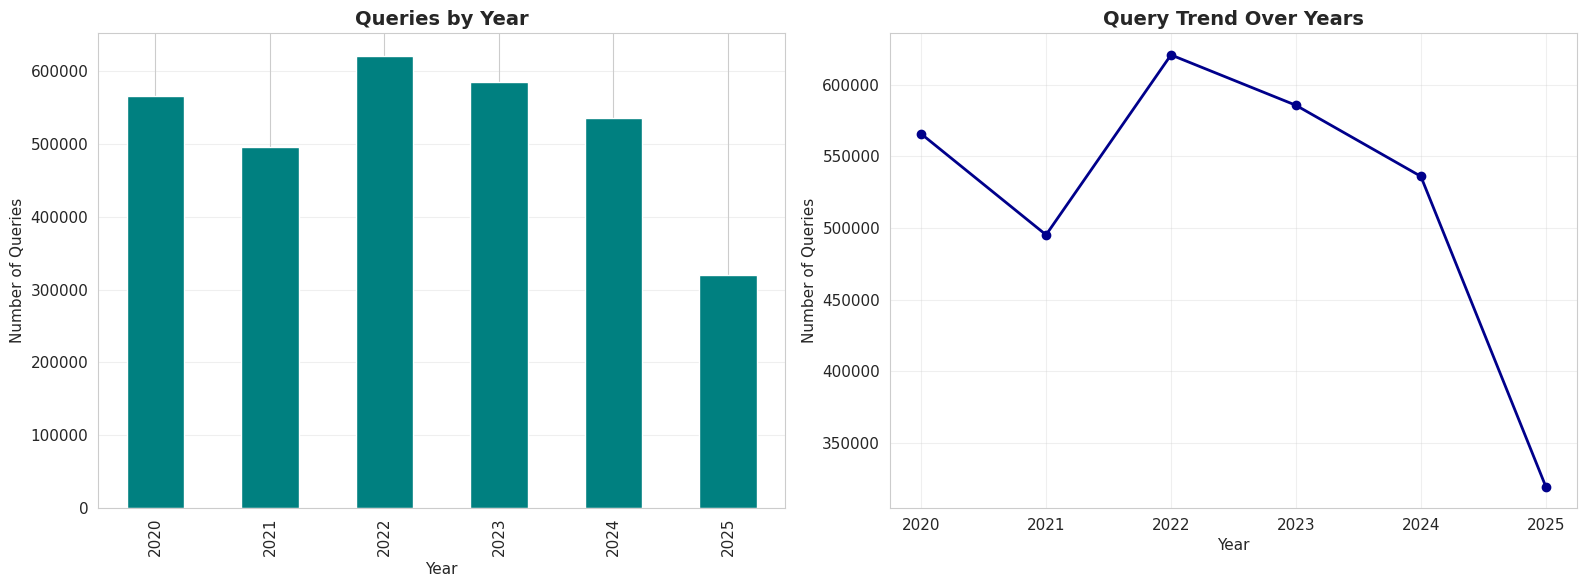


 Records by Month:
  Jan:  402,541 (12.89%)
  Feb:  314,716 (10.08%)
  Mar:  318,209 (10.19%)
  Apr:  186,236 ( 5.96%)
  May:  145,683 ( 4.66%)
  Jun:  270,971 ( 8.68%)
  Jul:  306,722 ( 9.82%)
  Aug:  214,999 ( 6.88%)
  Sep:  261,373 ( 8.37%)
  Oct:  253,382 ( 8.11%)
  Nov:  187,492 ( 6.00%)
  Dec:  260,703 ( 8.35%)


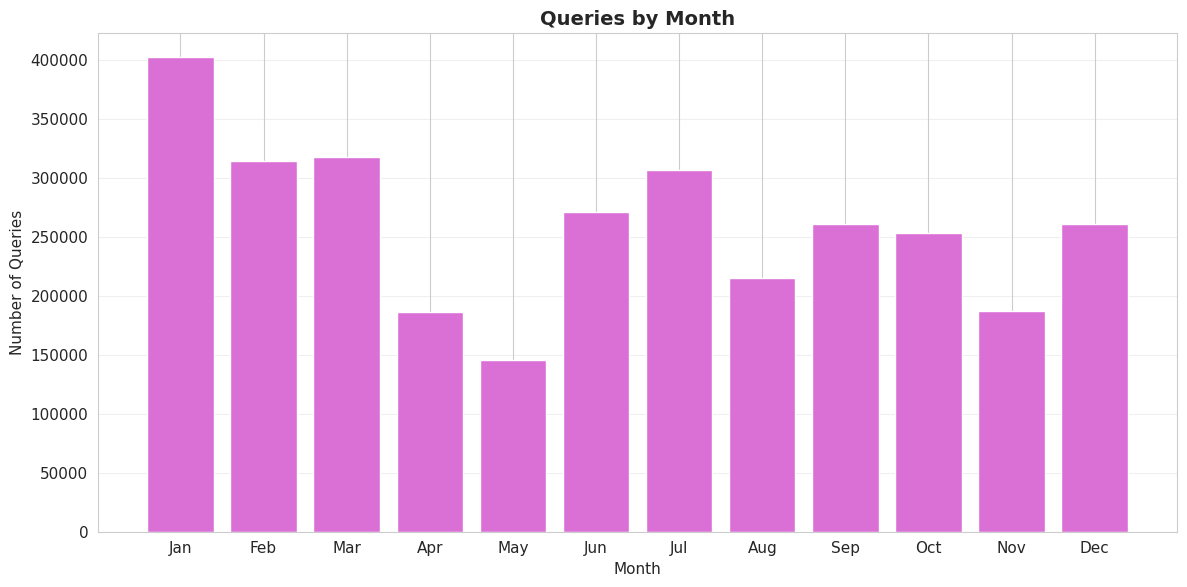


 Records by Season:
  ⚠️ No season data available (all values are 'Unknown')

 Monthly Query Distribution by Year:

Monthly Query Distribution:
             Jan    Feb    Mar    Apr    May    Jun    Jul    Aug    Sep  \
year_int                                                                   
2020      103243  74072  73692      0      0  47316  57689  51324  57303   
2021       58295  56392  55694  37172    120  11062      0  10283  56876   
2022       90864  46736  38731  33566  34395  55831  65642  55506  51880   
2023       54567  37328  61012  41701  39769  51746  71372  54251  45955   
2024       39095  50020  52132  37126  33697  56245  59124  43635  49359   
2025       56477  50168  36948  36671  37702  48771  52895      0      0   

            Oct    Nov    Dec  
year_int                       
2020      39413  23071  38596  
2021      70586  56804  81938  
2022      60613  39624  47385  
2023      39556  42137  46239  
2024      43214  25856  46545  
2025          0      0

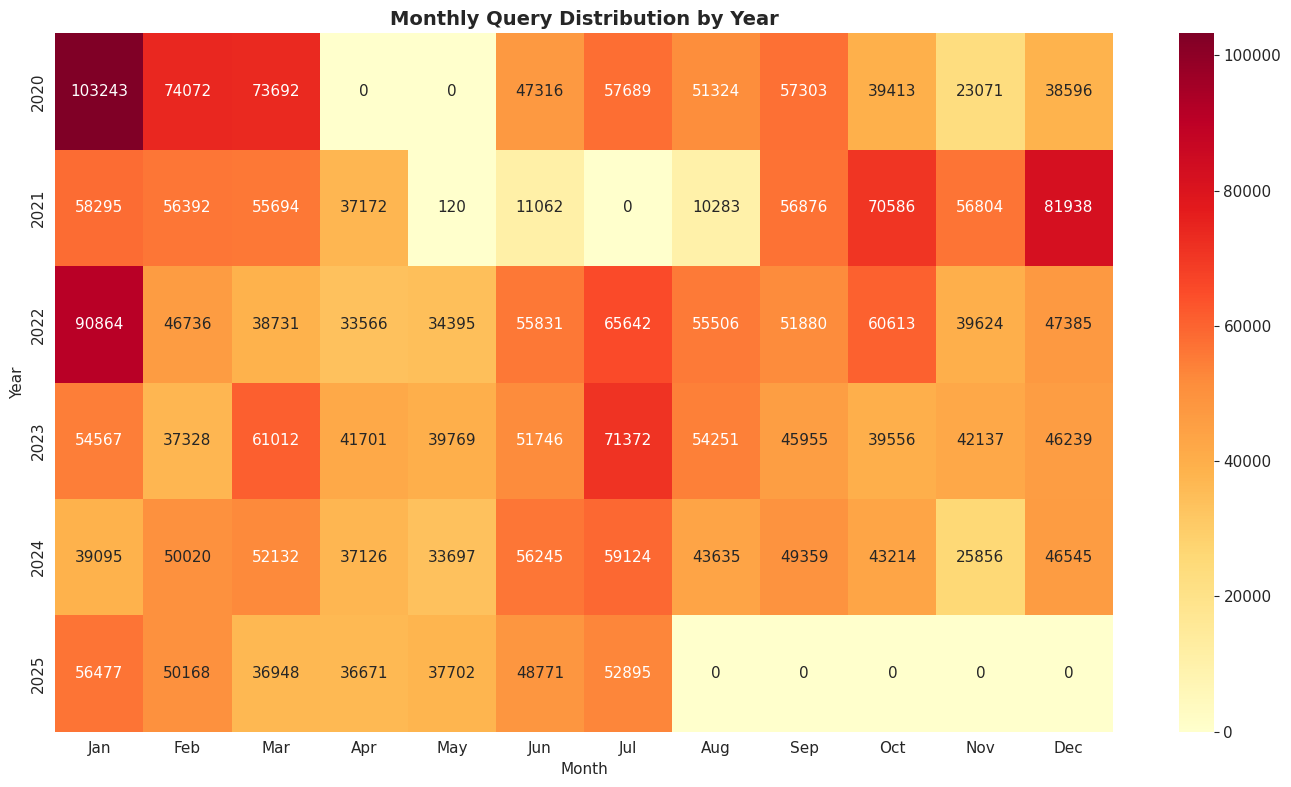


 Quarterly Analysis:

Records by Quarter:
  Q1 (Jan-Mar)   : 1,035,466 (33.16%)
  Q2 (Apr-Jun)   :  602,890 (19.30%)
  Q3 (Jul-Sep)   :  783,094 (25.07%)
  Q4 (Oct-Dec)   :  701,577 (22.46%)


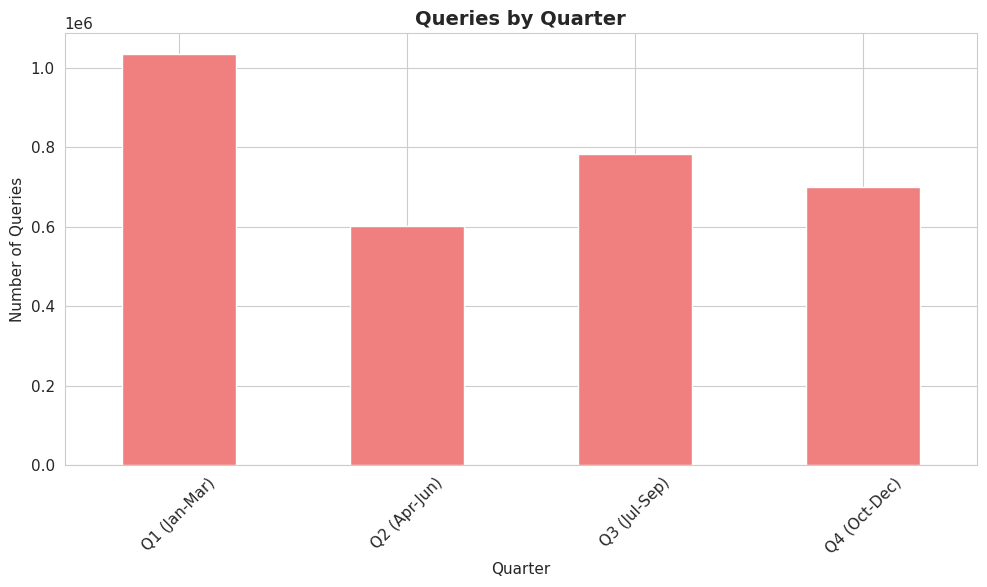


 Yearly Growth Analysis:

Year-over-Year Growth:
  2020: 565,719 (baseline)
  2021: 495,222 (↓ 12.5%)
  2022: 620,773 (↑ 25.4%)
  2023: 585,633 (↓ 5.7%)
  2024: 536,048 (↓ 8.5%)
  2025: 319,632 (↓ 40.4%)

 Temporal Analysis Complete!


In [36]:
# ============================================
# SECTION 4: TEMPORAL ANALYSIS (FIXED)
# ============================================

print("\n" + "="*80)
print("SECTION 4: TEMPORAL ANALYSIS")
print("="*80)

if 'year' in df.columns:
    # Handle NaN values before converting to int
    df_clean = df.dropna(subset=['year']).copy()


    # Convert year to int (now that NaN are handled)
    df_clean['year'] = df_clean['year'].astype(int)
    year_counts = df_clean['year'].value_counts().sort_index()

    print("\n Records by Year:")
    for year, count in year_counts.items():
        pct = (count / len(df_clean)) * 100
        print(f"  {int(year)}: {count:8,} ({pct:5.2f}%)")

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart
    year_counts.plot(kind='bar', ax=axes[0], color='teal')
    axes[0].set_title('Queries by Year', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Number of Queries')
    axes[0].grid(axis='y', alpha=0.3)

    # Line chart with trend
    year_counts.plot(kind='line', marker='o', ax=axes[1], color='darkblue', linewidth=2)
    axes[1].set_title('Query Trend Over Years', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Number of Queries')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if 'month' in df.columns:
    # Handle NaN values in month column
    df_clean = df.dropna(subset=['month']).copy()

    # Convert month to int
    df_clean['month_int'] = df_clean['month'].astype(int)
    month_counts = df_clean['month_int'].value_counts().sort_index()

    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    print("\n Records by Month:")
    for i, count in month_counts.items():
        if 1 <= i <= 12:
            pct = (count / len(df_clean)) * 100
            print(f"  {month_names[i-1]:3s}: {count:8,} ({pct:5.2f}%)")

    # Visualize
    fig, ax = plt.subplots(figsize=(12, 6))
    # Create labels for months that exist
    labels = [month_names[i-1] for i in month_counts.index if 1 <= i <= 12]
    values = [count for i, count in month_counts.items() if 1 <= i <= 12]

    ax.bar(labels, values, color='orchid')
    ax.set_title('Queries by Month', fontsize=14, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of Queries')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

if 'Season' in df.columns:
    # Clean Season column
    df['Season_clean'] = df['Season'].fillna('Unknown').astype(str).str.strip()
    season_counts = df['Season_clean'].value_counts()

    print("\n Records by Season:")
    for season, count in season_counts.items():
        if season != 'Unknown':  # Skip Unknown for clarity
            pct = (count / len(df)) * 100
            print(f"  {season:10s}: {count:8,} ({pct:5.2f}%)")

    # Visualize - only show meaningful seasons
    season_counts_clean = season_counts[season_counts.index != 'Unknown']
    if len(season_counts_clean) > 0:
        fig, ax = plt.subplots(figsize=(8, 8))
        season_counts_clean.plot(kind='pie', ax=ax, autopct='%1.1f%%', startangle=90)
        ax.set_title('Queries by Season', fontsize=14, fontweight='bold')
        ax.set_ylabel('')
        plt.tight_layout()
        plt.show()
    else:
        print("  ⚠️ No season data available (all values are 'Unknown')")


# MONTH-YEAR HEATMAP


if 'year' in df.columns and 'month' in df.columns:
    print("\n Monthly Query Distribution by Year:")

    # Clean data for heatmap
    df_clean = df.dropna(subset=['year', 'month']).copy()
    df_clean['year_int'] = df_clean['year'].astype(int)
    df_clean['month_int'] = df_clean['month'].astype(int)

    # Filter valid months (1-12)
    df_clean = df_clean[(df_clean['month_int'] >= 1) & (df_clean['month_int'] <= 12)]

    if len(df_clean) > 0:
        # Create pivot table
        pivot = pd.crosstab(df_clean['year_int'], df_clean['month_int'])

        # Rename columns to month names
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        pivot.columns = [month_names[i-1] for i in pivot.columns]

        print("\nMonthly Query Distribution:")
        print(pivot)

        # Visualize heatmap
        fig, ax = plt.subplots(figsize=(14, 8))
        sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
        ax.set_title('Monthly Query Distribution by Year', fontsize=14, fontweight='bold')
        ax.set_xlabel('Month')
        ax.set_ylabel('Year')
        plt.tight_layout()
        plt.show()


# QUARTERLY ANALYSIS


if 'month' in df.columns:
    print("\n Quarterly Analysis:")

    # Clean data
    df_clean = df.dropna(subset=['month']).copy()
    df_clean['month_int'] = df_clean['month'].astype(int)

    def get_quarter(month):
        """Get quarter from month"""
        if month in [1, 2, 3]:
            return 'Q1 (Jan-Mar)'
        elif month in [4, 5, 6]:
            return 'Q2 (Apr-Jun)'
        elif month in [7, 8, 9]:
            return 'Q3 (Jul-Sep)'
        elif month in [10, 11, 12]:
            return 'Q4 (Oct-Dec)'
        else:
            return 'Unknown'

    df_clean['quarter'] = df_clean['month_int'].apply(get_quarter)

    # Filter out Unknown
    quarter_df = df_clean[df_clean['quarter'] != 'Unknown']
    quarter_counts = quarter_df['quarter'].value_counts()

    # Order quarters
    quarter_order = ['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)']
    quarter_counts = quarter_counts.reindex(quarter_order)

    print("\nRecords by Quarter:")
    for quarter, count in quarter_counts.items():
        if pd.notna(count):
            pct = (count / len(quarter_df)) * 100 if len(quarter_df) > 0 else 0
            print(f"  {quarter:15s}: {count:8,} ({pct:5.2f}%)")

    # Visualize
    if len(quarter_counts.dropna()) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        quarter_counts.dropna().plot(kind='bar', ax=ax, color='lightcoral')
        ax.set_title('Queries by Quarter', fontsize=14, fontweight='bold')
        ax.set_xlabel('Quarter')
        ax.set_ylabel('Number of Queries')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()


# YEARLY GROWTH ANALYSIS


if 'year' in df.columns:
    print("\n Yearly Growth Analysis:")

    # Clean data
    df_clean = df.dropna(subset=['year']).copy()
    df_clean['year'] = df_clean['year'].astype(int)
    year_counts = df_clean['year'].value_counts().sort_index()

    # Calculate growth
    growth_df = pd.DataFrame({
        'Year': year_counts.index,
        'Count': year_counts.values
    })
    growth_df['Growth'] = growth_df['Count'].pct_change() * 100
    growth_df['Growth'] = growth_df['Growth'].fillna(0)

    print("\nYear-over-Year Growth:")
    for _, row in growth_df.iterrows():
        year = int(row['Year'])
        count = int(row['Count'])
        growth = row['Growth']
        if growth > 0:
            print(f"  {year}: {count:,} (↑ {growth:.1f}%)")
        elif growth < 0:
            print(f"  {year}: {count:,} (↓ {abs(growth):.1f}%)")
        else:
            print(f"  {year}: {count:,} (baseline)")

print("\n Temporal Analysis Complete!")

### LANGUAGE ANALYSIS


SECTION 5: LANGUAGE ANALYSIS
Analyzing language on 100,000 sample records...

 Query Language Distribution:
  english   :   99,979 (99.98%)
  mixed     :       20 ( 0.02%)
  unknown   :        1 ( 0.00%)

📊 Answer Language Distribution:
  hindi     :   98,803 (98.80%)
  english   :      873 ( 0.87%)
  mixed     :      278 ( 0.28%)
  unknown   :       41 ( 0.04%)
  telugu    :        5 ( 0.01%)


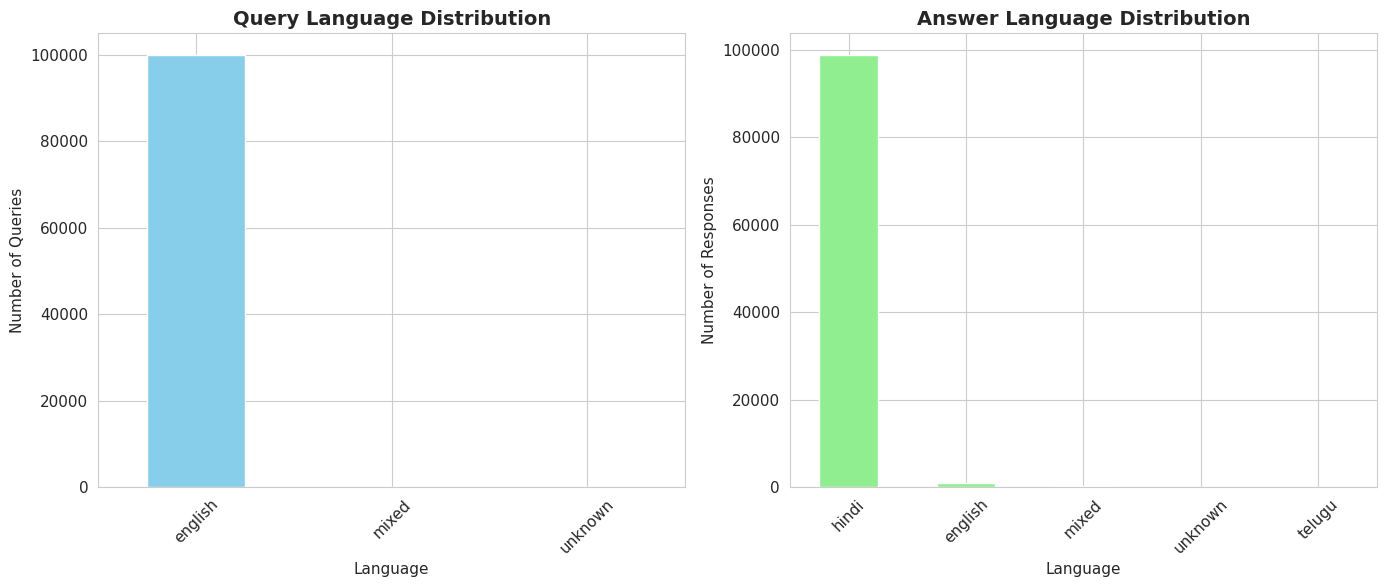

In [37]:
print("\n" + "="*80)
print("SECTION 5: LANGUAGE ANALYSIS")
print("="*80)

def detect_language(text):
    """Detect language of text"""
    if pd.isna(text) or text == '' or len(str(text)) < 3:
        return 'unknown'

    text = str(text)

    # Check for Devanagari (Hindi, Marathi, etc.)
    devanagari = re.search(r'[\u0900-\u097F]', text)
    if devanagari:
        devanagari_chars = len(re.findall(r'[\u0900-\u097F]', text))
        total_chars = len(re.sub(r'\s', '', text))
        if total_chars > 0 and devanagari_chars / total_chars > 0.3:
            return 'hindi'

    # Check for Tamil
    if re.search(r'[\u0B80-\u0BFF]', text):
        return 'tamil'

    # Check for Telugu
    if re.search(r'[\u0C00-\u0C7F]', text):
        return 'telugu'

    # Check for Kannada
    if re.search(r'[\u0C80-\u0CFF]', text):
        return 'kannada'

    # Check for Malayalam
    if re.search(r'[\u0D00-\u0D7F]', text):
        return 'malayalam'

    # Check for English
    english_chars = len(re.findall(r'[a-zA-Z]', text))
    total_chars = len(re.sub(r'\s', '', text))
    if total_chars > 0 and english_chars / total_chars > 0.5:
        return 'english'

    return 'mixed'

if 'QueryText' in df.columns and 'KccAns' in df.columns:
    # Sample for language detection (to avoid processing all 3M records)
    sample_size = min(100000, len(df))
    df_sample = df.sample(sample_size, random_state=42)

    print(f"Analyzing language on {sample_size:,} sample records...")

    # Detect languages
    df_sample['query_lang'] = df_sample['QueryText'].apply(detect_language)
    df_sample['answer_lang'] = df_sample['KccAns'].apply(detect_language)

    query_langs = df_sample['query_lang'].value_counts()
    answer_langs = df_sample['answer_lang'].value_counts()

    print("\n Query Language Distribution:")
    for lang, count in query_langs.items():
        pct = (count / len(df_sample)) * 100
        print(f"  {lang:10s}: {count:8,} ({pct:5.2f}%)")

    print("\n📊 Answer Language Distribution:")
    for lang, count in answer_langs.items():
        pct = (count / len(df_sample)) * 100
        print(f"  {lang:10s}: {count:8,} ({pct:5.2f}%)")

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    query_langs.plot(kind='bar', ax=axes[0], color='skyblue')
    axes[0].set_title('Query Language Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Language')
    axes[0].set_ylabel('Number of Queries')
    axes[0].tick_params(axis='x', rotation=45)

    answer_langs.plot(kind='bar', ax=axes[1], color='lightgreen')
    axes[1].set_title('Answer Language Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Language')
    axes[1].set_ylabel('Number of Responses')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

### TEXT LENGTH DISTRIBUTION


SECTION 6: TEXT LENGTH DISTRIBUTION

📊 Query Text Length Statistics:
count    3.123029e+06
mean     5.432476e+01
std      2.291064e+01
min      0.000000e+00
25%      2.900000e+01
50%      5.400000e+01
75%      7.100000e+01
max      6.273000e+03
Name: QueryText_length, dtype: float64

📊 Answer Text Length Statistics:
count    3.123029e+06
mean     2.093222e+02
std      1.115539e+02
min      0.000000e+00
25%      1.190000e+02
50%      2.030000e+02
75%      2.750000e+02
max      1.720500e+04
Name: KccAns_length, dtype: float64

 Outlier Boundaries:
  Query Text:
    • IQR Upper Bound: 134 characters
    • 95th Percentile: 85 characters
    • 99th Percentile: 103 characters
    • Max: 6273 characters

  Answer Text:
    • IQR Upper Bound: 509 characters
    • 95th Percentile: 392 characters
    • 99th Percentile: 470 characters
    • Max: 17205 characters

 Visualization Range (95th percentile):
  Query: 0 - 85 characters
  Answer: 0 - 392 characters


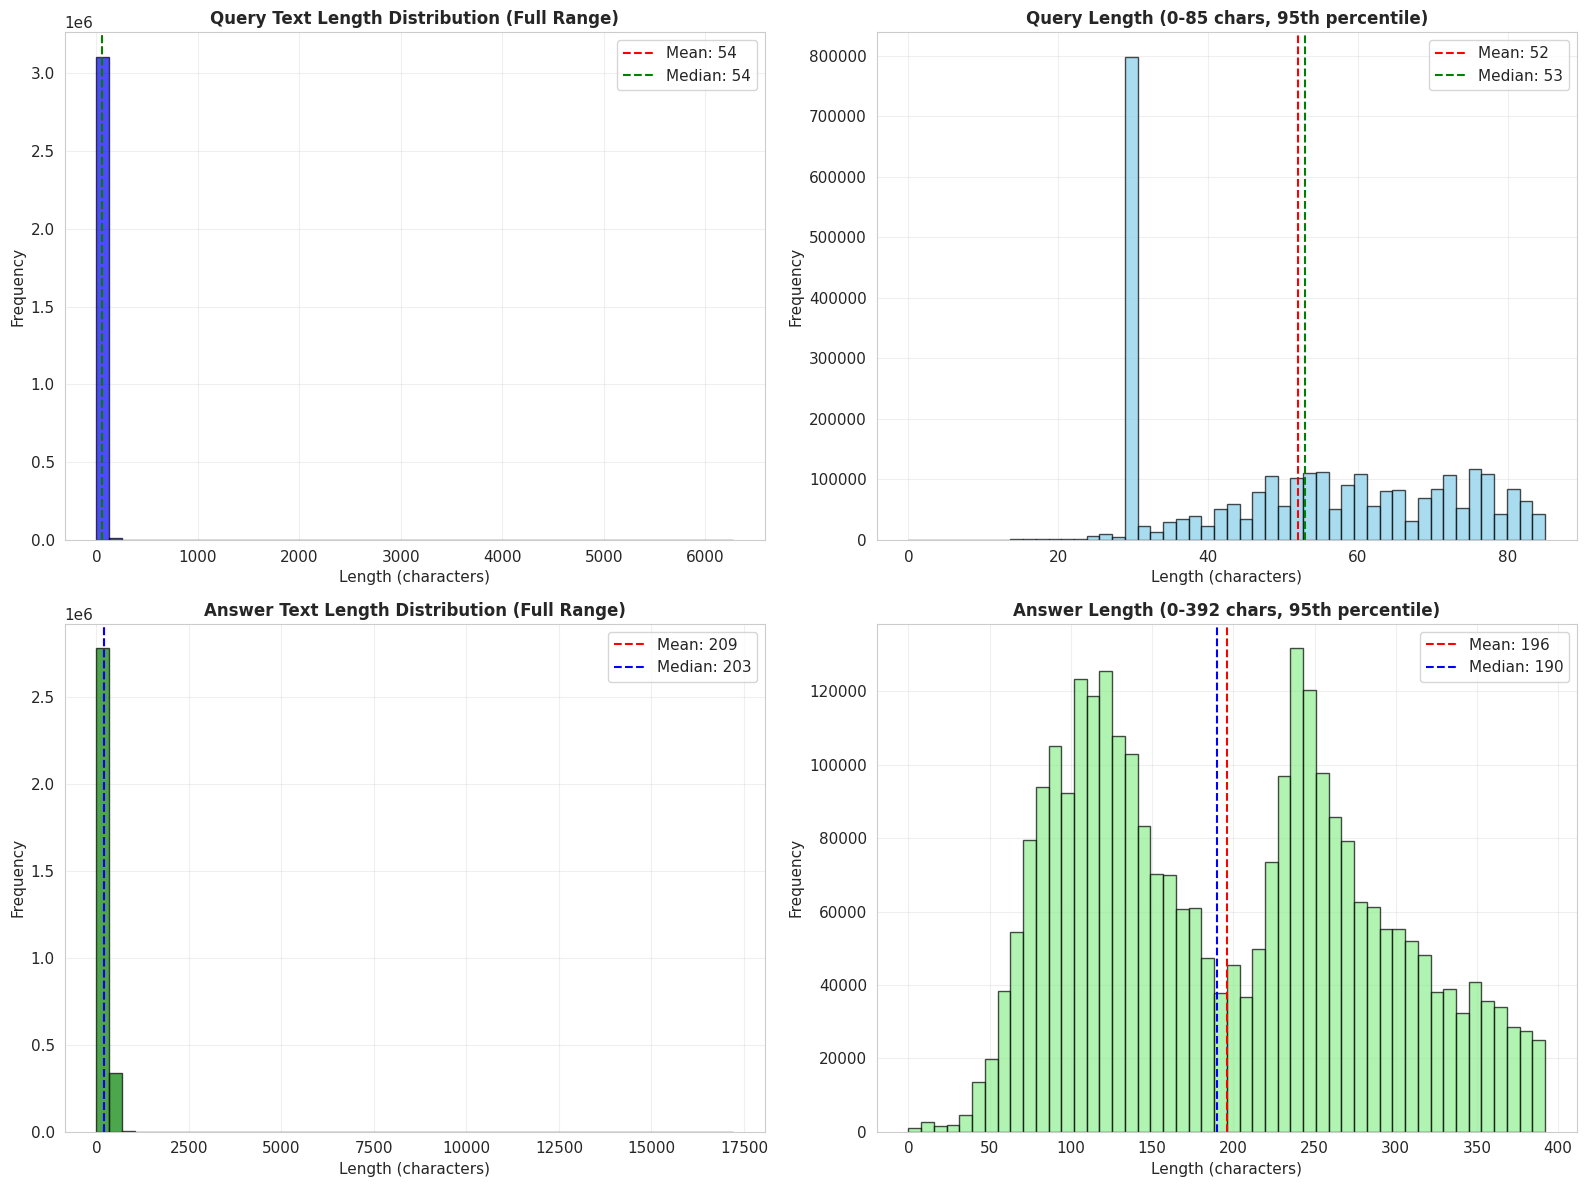

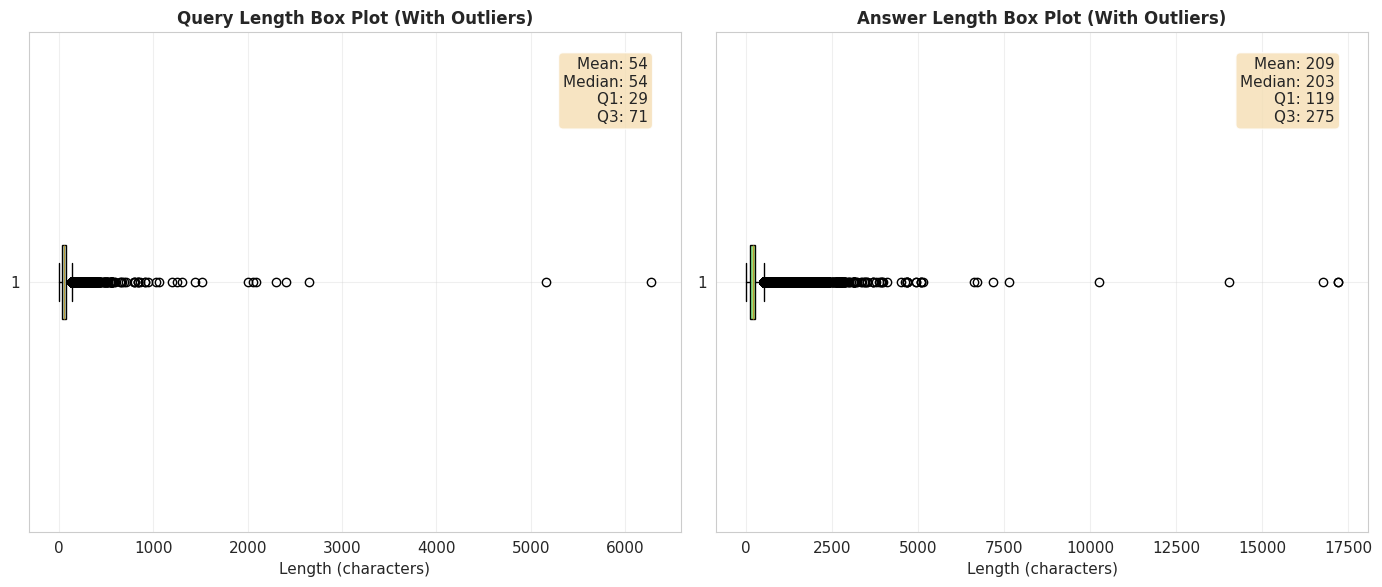

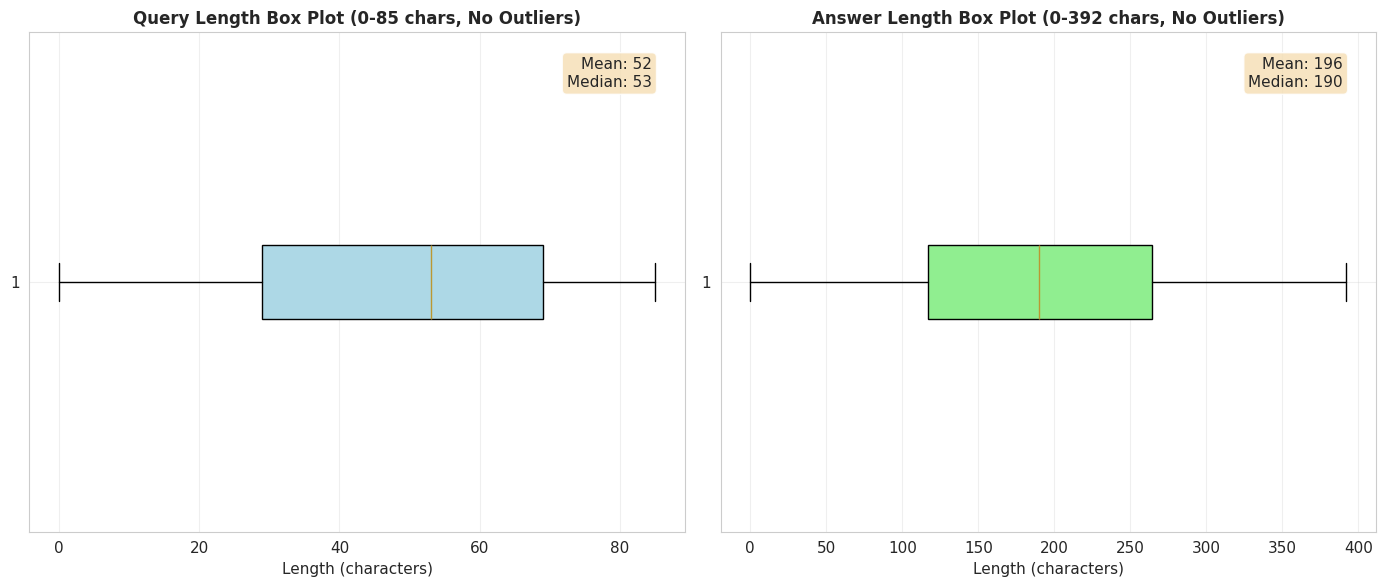


 Query vs Answer Length Comparison:
   Metric       Query       Answer
     Mean   54.324763   209.322162
   Median   54.000000   203.000000
      Min    0.000000     0.000000
      Max 6273.000000 17205.000000
      Std   22.910639   111.553896
95th %ile   85.000000   392.000000

 RAG Chunking Recommendations:

Combined Q&A Length Statistics:
  • Mean: 264 characters
  • Median: 260 characters
  • 75th percentile: 333 characters
  • 90th percentile: 396 characters
  • 95th percentile: 432 characters
  • Max: 17252 characters

 Recommended chunk size: 512 characters (MuRIL limit)
 Overlap: 50 characters
 98.9% of records fit in 512 chars

 Outliers (>95th percentile):
  • Query outliers: 144,405 (4.62%)
  • Answer outliers: 153,897 (4.93%)

 Visualization Range Used:
  • Query: 0-85 characters (shows 95% of data)
  • Answer: 0-392 characters (shows 95% of data)
  • Box plots: Show full range with outliers

 Text Length Analysis Complete!


In [39]:
print("\n" + "="*80)
print("SECTION 6: TEXT LENGTH DISTRIBUTION")
print("="*80)

if 'QueryText' in df.columns and 'KccAns' in df.columns:
    # Calculate lengths
    df['QueryText_length'] = df['QueryText'].fillna('').astype(str).apply(len)
    df['KccAns_length'] = df['KccAns'].fillna('').astype(str).apply(len)

    print("\n📊 Query Text Length Statistics:")
    print(df['QueryText_length'].describe())

    print("\n📊 Answer Text Length Statistics:")
    print(df['KccAns_length'].describe())

    # IDENTIFY OUTLIER BOUNDARIES

    # Calculate IQR for Query
    Q1_query = df['QueryText_length'].quantile(0.25)
    Q3_query = df['QueryText_length'].quantile(0.75)
    IQR_query = Q3_query - Q1_query
    upper_bound_query = Q3_query + 1.5 * IQR_query

    # Calculate IQR for Answer
    Q1_answer = df['KccAns_length'].quantile(0.25)
    Q3_answer = df['KccAns_length'].quantile(0.75)
    IQR_answer = Q3_answer - Q1_answer
    upper_bound_answer = Q3_answer + 1.5 * IQR_answer

    # Calculate 95th and 99th percentiles
    p95_query = df['QueryText_length'].quantile(0.95)
    p99_query = df['QueryText_length'].quantile(0.99)
    p95_answer = df['KccAns_length'].quantile(0.95)
    p99_answer = df['KccAns_length'].quantile(0.99)

    print("\n Outlier Boundaries:")
    print(f"  Query Text:")
    print(f"    • IQR Upper Bound: {upper_bound_query:.0f} characters")
    print(f"    • 95th Percentile: {p95_query:.0f} characters")
    print(f"    • 99th Percentile: {p99_query:.0f} characters")
    print(f"    • Max: {df['QueryText_length'].max():.0f} characters")
    print(f"\n  Answer Text:")
    print(f"    • IQR Upper Bound: {upper_bound_answer:.0f} characters")
    print(f"    • 95th Percentile: {p95_answer:.0f} characters")
    print(f"    • 99th Percentile: {p99_answer:.0f} characters")
    print(f"    • Max: {df['KccAns_length'].max():.0f} characters")

    # RECOMMENDED VISUALIZATION RANGE

    # Use 95th percentile for visualization to show most data
    query_vis_limit = min(p95_query, 500)  # Cap at 500 for readability
    answer_vis_limit = min(p95_answer, 1000)  # Cap at 1000 for readability

    print(f"\n Visualization Range (95th percentile):")
    print(f"  Query: 0 - {query_vis_limit:.0f} characters")
    print(f"  Answer: 0 - {answer_vis_limit:.0f} characters")

    # ============================================
    # VISUALIZATION 1: HISTOGRAM WITH OUTLIER CAP
    # ============================================

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Query histogram - Full range
    axes[0, 0].hist(df['QueryText_length'], bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[0, 0].axvline(df['QueryText_length'].mean(), color='red', linestyle='--',
                       label=f"Mean: {df['QueryText_length'].mean():.0f}")
    axes[0, 0].axvline(df['QueryText_length'].median(), color='green', linestyle='--',
                       label=f"Median: {df['QueryText_length'].median():.0f}")
    axes[0, 0].set_title('Query Text Length Distribution (Full Range)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Length (characters)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    # Query histogram - Capped at 95th percentile
    query_capped = df['QueryText_length'][df['QueryText_length'] <= query_vis_limit]
    axes[0, 1].hist(query_capped, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 1].axvline(query_capped.mean(), color='red', linestyle='--',
                       label=f"Mean: {query_capped.mean():.0f}")
    axes[0, 1].axvline(query_capped.median(), color='green', linestyle='--',
                       label=f"Median: {query_capped.median():.0f}")
    axes[0, 1].set_title(f'Query Length (0-{query_vis_limit:.0f} chars, 95th percentile)',
                         fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Length (characters)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Answer histogram - Full range
    axes[1, 0].hist(df['KccAns_length'], bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1, 0].axvline(df['KccAns_length'].mean(), color='red', linestyle='--',
                       label=f"Mean: {df['KccAns_length'].mean():.0f}")
    axes[1, 0].axvline(df['KccAns_length'].median(), color='blue', linestyle='--',
                       label=f"Median: {df['KccAns_length'].median():.0f}")
    axes[1, 0].set_title('Answer Text Length Distribution (Full Range)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Length (characters)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # Answer histogram - Capped at 95th percentile
    answer_capped = df['KccAns_length'][df['KccAns_length'] <= answer_vis_limit]
    axes[1, 1].hist(answer_capped, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[1, 1].axvline(answer_capped.mean(), color='red', linestyle='--',
                       label=f"Mean: {answer_capped.mean():.0f}")
    axes[1, 1].axvline(answer_capped.median(), color='blue', linestyle='--',
                       label=f"Median: {answer_capped.median():.0f}")
    axes[1, 1].set_title(f'Answer Length (0-{answer_vis_limit:.0f} chars, 95th percentile)',
                         fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Length (characters)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # VISUALIZATION 2: BOX PLOTS WITH OUTLIERS

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Box plot - Query (with outliers)
    box_query = axes[0].boxplot(df['QueryText_length'], vert=False, patch_artist=True,
                                showfliers=True,  # Show outliers
                                boxprops=dict(facecolor='lightblue'))
    axes[0].set_title('Query Length Box Plot (With Outliers)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Length (characters)')
    axes[0].grid(alpha=0.3)
    # Add statistics
    stats_query = df['QueryText_length'].describe()
    axes[0].text(0.95, 0.95,
                 f'Mean: {stats_query["mean"]:.0f}\nMedian: {stats_query["50%"]:.0f}\nQ1: {stats_query["25%"]:.0f}\nQ3: {stats_query["75%"]:.0f}',
                 transform=axes[0].transAxes, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # Box plot - Answer (with outliers)
    box_answer = axes[1].boxplot(df['KccAns_length'], vert=False, patch_artist=True,
                                 showfliers=True,  # Show outliers
                                 boxprops=dict(facecolor='lightgreen'))
    axes[1].set_title('Answer Length Box Plot (With Outliers)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Length (characters)')
    axes[1].grid(alpha=0.3)
    # Add statistics
    stats_answer = df['KccAns_length'].describe()
    axes[1].text(0.95, 0.95,
                 f'Mean: {stats_answer["mean"]:.0f}\nMedian: {stats_answer["50%"]:.0f}\nQ1: {stats_answer["25%"]:.0f}\nQ3: {stats_answer["75%"]:.0f}',
                 transform=axes[1].transAxes, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()

    # VISUALIZATION 3: BOX PLOTS WITHOUT OUTLIERS (Zoomed)


    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Box plot - Query (without outliers, zoomed)
    # Use 95th percentile as limit
    query_no_outliers = df['QueryText_length'][df['QueryText_length'] <= query_vis_limit]
    axes[0].boxplot(query_no_outliers, vert=False, patch_artist=True,
                    showfliers=False,  # Hide outliers
                    boxprops=dict(facecolor='lightblue'))
    axes[0].set_title(f'Query Length Box Plot (0-{query_vis_limit:.0f} chars, No Outliers)',
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Length (characters)')
    axes[0].grid(alpha=0.3)
    # Statistics
    stats_query_no_out = query_no_outliers.describe()
    axes[0].text(0.95, 0.95,
                 f'Mean: {stats_query_no_out["mean"]:.0f}\nMedian: {stats_query_no_out["50%"]:.0f}',
                 transform=axes[0].transAxes, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    # Box plot - Answer (without outliers, zoomed)
    answer_no_outliers = df['KccAns_length'][df['KccAns_length'] <= answer_vis_limit]
    axes[1].boxplot(answer_no_outliers, vert=False, patch_artist=True,
                    showfliers=False,  # Hide outliers
                    boxprops=dict(facecolor='lightgreen'))
    axes[1].set_title(f'Answer Length Box Plot (0-{answer_vis_limit:.0f} chars, No Outliers)',
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Length (characters)')
    axes[1].grid(alpha=0.3)
    # Statistics
    stats_answer_no_out = answer_no_outliers.describe()
    axes[1].text(0.95, 0.95,
                 f'Mean: {stats_answer_no_out["mean"]:.0f}\nMedian: {stats_answer_no_out["50%"]:.0f}',
                 transform=axes[1].transAxes, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()


    # QUERY VS ANSWER COMPARISON


    print("\n Query vs Answer Length Comparison:")
    comparison = pd.DataFrame({
        'Metric': ['Mean', 'Median', 'Min', 'Max', 'Std', '95th %ile'],
        'Query': [
            df['QueryText_length'].mean(),
            df['QueryText_length'].median(),
            df['QueryText_length'].min(),
            df['QueryText_length'].max(),
            df['QueryText_length'].std(),
            df['QueryText_length'].quantile(0.95)
        ],
        'Answer': [
            df['KccAns_length'].mean(),
            df['KccAns_length'].median(),
            df['KccAns_length'].min(),
            df['KccAns_length'].max(),
            df['KccAns_length'].std(),
            df['KccAns_length'].quantile(0.95)
        ]
    })
    print(comparison.to_string(index=False))

    # ============================================
    # CHUNKING RECOMMENDATIONS
    # ============================================

    print("\n RAG Chunking Recommendations:")
    print("="*60)

    # Calculate combined lengths
    df['combined_length'] = df['QueryText_length'] + df['KccAns_length']

    print(f"\nCombined Q&A Length Statistics:")
    print(f"  • Mean: {df['combined_length'].mean():.0f} characters")
    print(f"  • Median: {df['combined_length'].median():.0f} characters")
    print(f"  • 75th percentile: {df['combined_length'].quantile(0.75):.0f} characters")
    print(f"  • 90th percentile: {df['combined_length'].quantile(0.90):.0f} characters")
    print(f"  • 95th percentile: {df['combined_length'].quantile(0.95):.0f} characters")
    print(f"  • Max: {df['combined_length'].max():.0f} characters")

    print(f"\n Recommended chunk size: 512 characters (MuRIL limit)")
    print(f" Overlap: 50 characters")
    print(f" {df[df['combined_length'] <= 512].shape[0] / len(df) * 100:.1f}% of records fit in 512 chars")

    # Outlier counts
    outliers_query = len(df[df['QueryText_length'] > p95_query])
    outliers_answer = len(df[df['KccAns_length'] > p95_answer])

    print(f"\n Outliers (>95th percentile):")
    print(f"  • Query outliers: {outliers_query:,} ({outliers_query/len(df)*100:.2f}%)")
    print(f"  • Answer outliers: {outliers_answer:,} ({outliers_answer/len(df)*100:.2f}%)")

    print("\n Visualization Range Used:")
    print(f"  • Query: 0-{query_vis_limit:.0f} characters (shows 95% of data)")
    print(f"  • Answer: 0-{answer_vis_limit:.0f} characters (shows 95% of data)")
    print(f"  • Box plots: Show full range with outliers")

print("\n Text Length Analysis Complete!")

### MISSING VALUE ANALYSIS

In [42]:


print("\n" + "="*80)
print("SECTION 7: MISSING VALUE ANALYSIS")
print("="*80)

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_%': (df.isnull().sum() / len(df)) * 100
}).sort_values('Missing_%', ascending=False)

print("\n📊 Missing Values Summary:")
print(missing_df[missing_df['Missing_Count'] > 0].to_string(index=False))



SECTION 7: MISSING VALUE ANALYSIS

📊 Missing Values Summary:
      Column  Missing_Count  Missing_%
      Season        3123029 100.000000
      Sector           6372   0.204033
        Crop           6370   0.203969
   QueryType           4886   0.156451
    Category           3779   0.121004
   BlockName           1454   0.046557
      KccAns            559   0.017899
   QueryText             12   0.000384
DistrictName              7   0.000224
        year              2   0.000064
   StateName              2   0.000064
         day              2   0.000064
       month              2   0.000064
   CreatedOn              1   0.000032


In [44]:
print("\n" + "="*80)
print("SECTION 8: DUPLICATE ANALYSIS")
print("="*80)

# Exact duplicates
exact_duplicates = df.duplicated().sum()
print(f"\n Exact duplicate rows: {exact_duplicates:,} ({exact_duplicates/len(df)*100:.2f}%)")

# Check for duplicate queries
if 'QueryText' in df.columns:
    duplicate_queries = df['QueryText'].duplicated().sum()
    print(f" Duplicate queries: {duplicate_queries:,} ({duplicate_queries/len(df)*100:.2f}%)")

    # Show most common duplicate queries
    if duplicate_queries > 0:
        common_queries = df['QueryText'].value_counts().head(10)
        print("\n Most Common Duplicate Queries:")
        for query, count in common_queries.items():
            if count > 1:
                print(f"  '{query[:50]}...' appears {count} times")

# Check for duplicate IDs
if 'KCCCallID' in df.columns:
    duplicate_ids = df['KCCCallID'].duplicated().sum()
    print(f" Duplicate KCCCallIDs: {duplicate_ids:,} ({duplicate_ids/len(df)*100:.2f}%)")

# Check for duplicate QA pairs
if 'QueryText' in df.columns and 'KccAns' in df.columns:
    qa_duplicates = df[['QueryText', 'KccAns']].duplicated().sum()
    print(f" Duplicate Q&A pairs: {qa_duplicates:,} ({qa_duplicates/len(df)*100:.2f}%)")

# Near duplicate detection (sample)
print("\n Near-duplicate detection (sample 1000 records):")
sample_size = min(1000, len(df))
df_sample = df.sample(sample_size, random_state=42)

def is_similar(text1, text2, threshold=0.85):
    if pd.isna(text1) or pd.isna(text2):
        return False
    return SequenceMatcher(None, str(text1), str(text2)).ratio() >= threshold

similar_pairs = []
for i in range(min(200, len(df_sample))):
    for j in range(i+1, min(i+5, len(df_sample))):
        if is_similar(df_sample.iloc[i]['QueryText'], df_sample.iloc[j]['QueryText']):
            similar_pairs.append((i, j))

print(f"  Found {len(similar_pairs)} similar query pairs in sample")


SECTION 8: DUPLICATE ANALYSIS

 Exact duplicate rows: 0 (0.00%)
 Duplicate queries: 2,146,154 (68.72%)

 Most Common Duplicate Queries:
  'Farmer asked query on Weather...' appears 781352 times
  'Tell me about the Pradhan Mantri Kisan Samman Nidh...' appears 9178 times
  'Information about Pradhan Mantri Kisan Samman Nidh...' appears 5822 times
  'Tell About Information of Pradhanmantri Kisan Samm...' appears 4752 times
  'Information about PM- Kisan Samman Nidhi Yojana (P...' appears 4441 times
  'Information about pm kisan samman nidhi status ? ...' appears 4360 times
  'Information about Prime Minister Kisan Samman Nidh...' appears 4267 times
  'Information About Pradhan mantri kisan samman nidh...' appears 4221 times
  'Provide information related to Pradhan Mantri Kisa...' appears 3974 times
  'Information about beneficiary status of PM Kisan S...' appears 3838 times
 Duplicate KCCCallIDs: 410,624 (13.15%)
 Duplicate Q&A pairs: 816,808 (26.15%)

 Near-duplicate detection (sample

### SAMPLE RECORDS

In [45]:
print("\n" + "="*80)
print("SECTION 9: SAMPLE RECORDS")
print("="*80)

# Sample by Category
if 'Category' in df.columns:
    print("\n Sample records by Category:")
    categories = df['Category'].value_counts().head(5).index.tolist()

    for category in categories:
        print(f"\n--- Category: {category} ---")
        sample = df[df['Category'] == category].head(2)
        for _, row in sample.iterrows():
            print(f"  Query: {row.get('QueryText', 'N/A')[:150]}...")
            print(f"  Answer: {row.get('KccAns', 'N/A')[:150]}...")
            print(f"  District: {row.get('DistrictName', 'N/A')}")
            print(f"  Crop: {row.get('Crop', 'N/A')}")
            print(f"  Year: {row.get('year', 'N/A')}")
            print("  " + "-"*50)

# Sample by Query Type
if 'QueryType' in df.columns:
    print("\n Sample records by Query Type:")
    query_types = df['QueryType'].value_counts().head(5).index.tolist()

    for qtype in query_types:
        print(f"\n--- Query Type: {qtype} ---")
        sample = df[df['QueryType'] == qtype].head(2)
        for _, row in sample.iterrows():
            print(f"  Query: {row.get('QueryText', 'N/A')[:150]}...")
            print(f"  Answer: {row.get('KccAns', 'N/A')[:150]}...")
            print(f"  Crop: {row.get('Crop', 'N/A')}")
            print("  " + "-"*50)



SECTION 9: SAMPLE RECORDS

 Sample records by Category:

--- Category: Others ---
  Query: Information about application status of PM Kisan Samman Nidhi scheme...?

...
  Answer: श्रीमान जी प्रधानमंत्री किसान सम्मान निधि योजना का आवेदन राज्य/जिला के स्वीकृति के लिए लंबित है,अधिक जानकारी के लिए अपने जिले में कृषि उपनिदेशक कार्या...
  District: GONDA
  Crop: Others
  Year: 2020.0
  --------------------------------------------------
  Query: Farmer asked query on Weather...
  Answer: श्रीमान जी आज से 30 जुलाई के बीच हल्की से भारी बारिश की संभावना है। आज का न्यूनतम तापमान 28 डिग्री सेल्सियस और अधिकतम तापमान 31 डिग्री सेल्सियस और हवा...
  District: ALLAHABAD
  Crop: Others
  Year: 2020.0
  --------------------------------------------------

--- Category: Cereals ---
  Query: Dhaan ki fasal me top dressing ke samay kya prayog kare ...?...
  Answer: महोदय, धान में टॉप ड्रेसिंग के समय यूरिया 35 kg और जिंक सल्फेट 10 kg प्रति एकर की दर से नमी की अवस्था में प्रयोग करे |...
  District: SITAPUR
  